In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

In [3]:
dag_path        = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit"
hese_path       = f"{dag_path}/hese/"
hese_doug_path       = f"{dag_path}/hese/bdt_threshold_study_doug"

scan_dir_dict = {

    "benchmark": f"{hese_path}/SAY/hese_HESEBestfit_SPL_noineltrue_nosyst",

    "nominal": f"{hese_doug_path}/bdt1_0.333333_bdt2_0.366667",

    "plus1": f"{hese_doug_path}/bdt1_0.36_bdt2_0.366667",
    "plus2": f"{hese_doug_path}/bdt1_0.333333_bdt2_0.4",

    "min1": f"{hese_doug_path}/bdt1_0.3_bdt2_0.366667",
    "min2": f"{hese_doug_path}/bdt1_0.333333_bdt2_0.33",
}

In [4]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/bdt_threshold_study_doug/plots"
os.system(f"mkdir -p {plotting_path}")

0

In [24]:
# load the data
N_grid = 40 # 20 was standard
drop_unsuccessful = False
scan_dict = {}
data = {}
for name, scan_dir in scan_dir_dict.items():
    print(name)
    print(scan_dir)
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    if "newflavorparam" in name or "gf" in name:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_angle(scan_dict,name)
    else:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid=N_grid)


benchmark
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//SAY/hese_HESEBestfit_SPL_noineltrue_nosyst
removed stuff
nominal
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/bdt_threshold_study_doug/bdt1_0.333333_bdt2_0.366667
removed stuff
plus1
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/bdt_threshold_study_doug/bdt1_0.36_bdt2_0.366667
removed stuff
plus2
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/bdt_threshold_study_doug/bdt1_0.333333_bdt2_0.4
removed stuff
min1
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/bdt_threshold_study_doug/bdt1_0.3_bdt2_0.366667
removed stuff
min2
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/bdt_threshold_study_doug/bdt1_0.333333_bdt2_0.33
removed stuff


Compare my benchmark

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (benchmark / benchmark) at 68%: 1.0000
Area ratio (nominal / benchmark) at 68%: 1.0060


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

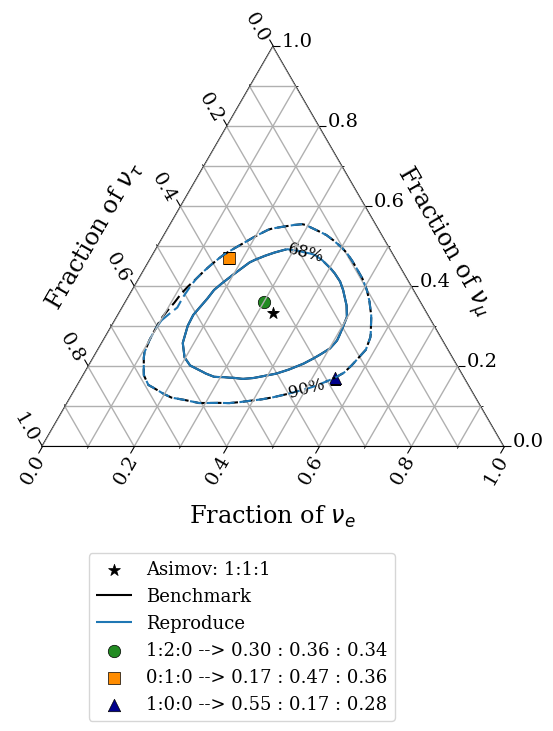

In [7]:
savename = f"compare benchmark"
names = [
f"benchmark",
f"nominal",
]
labels = [
    "Benchmark",
    "Reproduce",
]
C = compare_contours( data = data,
                names = names,
                labels = labels,
                levels = ["68%","90%"],
                title = "",
                scenarios = True,
                show_ts_labels=True,
                savepath = f"{plotting_path}/{savename}.png")

for name in names: compare_area( C, alt_key=name, base_key=names[0], levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (nominal / nominal) at 68%: 1.0000
Area ratio (plus1 / nominal) at 68%: 1.0070
Area ratio (plus2 / nominal) at 68%: 1.0054
Area ratio (min1 / nominal) at 68%: 1.0055
Area ratio (min2 / nominal) at 68%: 1.0062


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

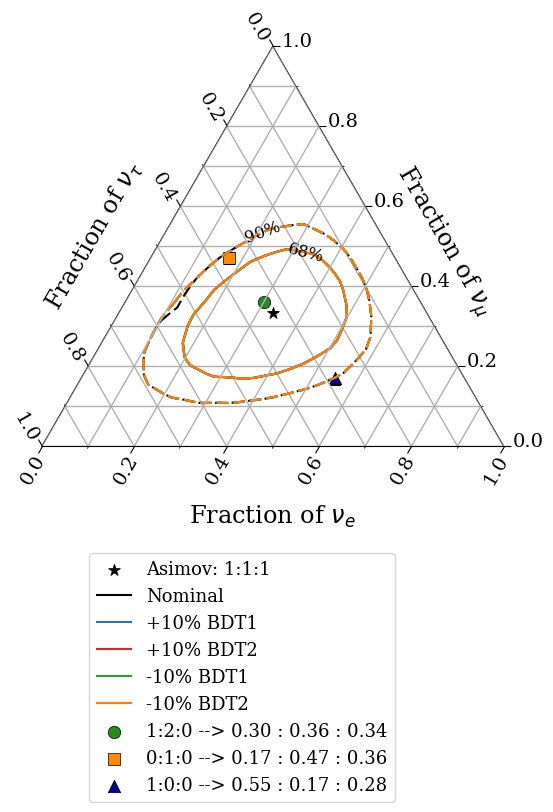

In [26]:
savename = f"compare benchmark"
names = [
f"nominal",
f"plus1",
f"plus2",
f"min1",
f"min2",
]
labels = [
    "Nominal",
    "+10% BDT1",
    "+10% BDT2",
    "-10% BDT1",
    "-10% BDT2",
]
C = compare_contours( data = data,
                names = names,
                labels = labels,
                levels = ["68%","90%"],
                title = "",
                scenarios = True,
                show_ts_labels=True,
                savepath = f"{plotting_path}/{savename}.png")

for name in names: compare_area( C, alt_key=name, base_key=names[0], levels=["68%"] )

I almost see no differences. Did I actually have different datasets?!

I check 
- /scratch/tvaneede/NNMFit/condor/21_05_2026_13_32_47/logs/freefit.err
- /data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/bdt_threshold_study_doug/bdt1_0.3_bdt2_0.366667/Fit_Configuration.yaml

I see the dataset

/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/split/IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_fluxlessweight/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.3_bdt2_0.366667_length_10//dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_fluxlessweight_double.parquet

which is slightly different in size.

The lower threshold is 0.1100001, which is correct.

bdt1_0.333333_bdt2_0.33 seems to be empty
- /scratch/tvaneede/NNMFit/condor/21_05_2026_13_32_58/freefit.err
Looks fine

Just like:
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/bdt_threshold_study_doug/bdt1_0.333333_bdt2_0.33/Fit_Configuration.yaml

In [23]:
name = "min2"
scan_dict[name].get_raw_df()
scan_dict[name].get_freefit()

# data[name]["ts"].hist()

KeyError: 'freefit'